PROYECTO DE SEPARACIÓN DE IMÁGENES DE UN DRON COMO SEÑALES ESPACIALES

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving DJI_0606.JPG to DJI_0606 (1).JPG
Se han subido 1 archivo(s). Vuelve a ejecutar esta celda para subir otro archivo.


Adquisición y preprocesamiento de imágenes

La lectura y el procesamiento de las imágenes se realizaron mediante la librería OpenCV (cv2). Debido a que esta biblioteca interpreta las imágenes utilizando el formato BGR, fue necesario transformarlas al formato RGB para garantizar una visualización correcta y una adecuada interpretación de los colores durante el análisis.

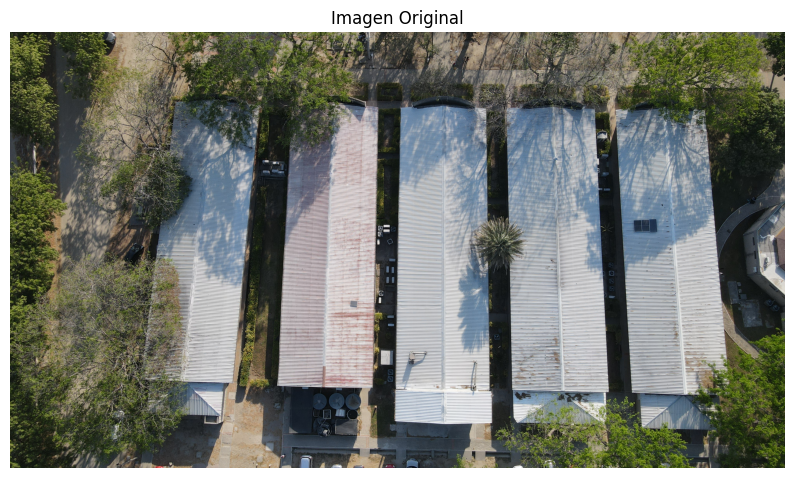

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Obtener nombre del archivo subido
nombre_imagen = list(uploaded.keys())[0]

# Leer imagen
img_bgr = cv2.imread(nombre_imagen)

# Convertir BGR -> RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Mostrar imagen
plt.figure(figsize=(10,6))
plt.imshow(img_rgb)
plt.title("Imagen Original")
plt.axis("off")
plt.show()

#**Separacion de canales RGB**

Una imagen en formato RGB puede representarse mediante tres matrices bidimensionales independientes, asociadas a los canales rojo (R), verde (G) y azul (B). Cada una de estas matrices contiene los valores de intensidad correspondientes a su componente de color, permitiendo analizar por separado la contribución de cada canal dentro de la señal espacial que conforma la imagen.


Dimensión canal R: (2250, 4000)
Dimensión canal G: (2250, 4000)
Dimensión canal B: (2250, 4000)


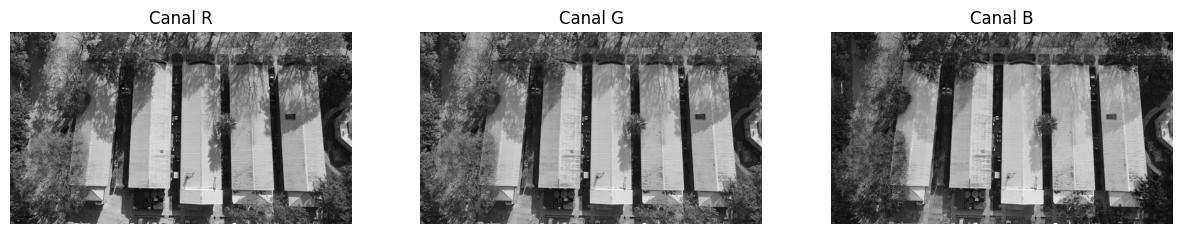

In [ ]:
# Separar canales RGB
R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

# Mostrar dimensiones
print("Dimensión canal R:", R.shape)
print("Dimensión canal G:", G.shape)
print("Dimensión canal B:", B.shape)

# Mostrar canales
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(R, cmap='gray')
plt.title("Canal R")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='gray')
plt.title("Canal G")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='gray')
plt.title("Canal B")
plt.axis("off")

plt.show()

Análisis Estadístico de los Canales RGB

Aunque las imágenes correspondientes a los canales RGB presentan una apariencia similar cuando se visualizan en escala de grises, cada una contiene valores numéricos de intensidad diferentes. Por esta razón, resulta necesario realizar un análisis estadístico que permita comparar cuantitativamente el comportamiento de cada canal.

Para ello, se calcularon estadísticas básicas de intensidad, como el valor promedio de los canales rojo (R), verde (G) y azul (B). Estos indicadores permiten evaluar la contribución relativa de cada componente de color a la imagen original y comprender mejor la distribución de los niveles de brillo presentes en la escena analizada.


In [ ]:
import numpy as np
#numpy es una libreria que maneja matrices y operaciones matematicas
print("Promedio canal R:", np.mean(R))
print("Promedio canal G:", np.mean(G))
print("Promedio canal B:", np.mean(B))

print("Mínimo R:", np.min(R), "Máximo R:", np.max(R))
print("Mínimo G:", np.min(G), "Máximo G:", np.max(G))
print("Mínimo B:", np.min(B), "Máximo B:", np.max(B))

Promedio canal R: 108.081931
Promedio canal G: 110.89742222222222
Promedio canal B: 102.90545822222222
Mínimo R: 0 Máximo R: 255
Mínimo G: 0 Máximo G: 255
Mínimo B: 0 Máximo B: 255


Los valores promedio de intensidad muestran diferencias entre los canales RGB. El canal azul presenta una intensidad promedio menor respecto a los canales rojo y verde, lo cual indica una respuesta distinta de las superficies de agua y vegetación presentes en la escena. Estas diferencias permiten utilizar la información espectral de los canales para tareas de segmentación.

# **Recorte de región de interés**

Para reducir falsas detecciones en árboles y sombras, se seleccionó una región de interés que contiene únicamente el área de los hángares.

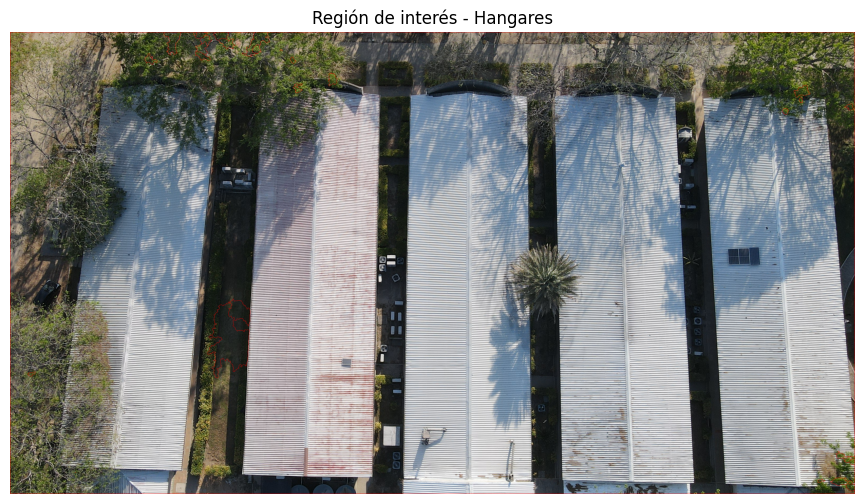

In [ ]:
# Recortar región de interés aproximada
# Formato: imagen[y1:y2, x1:x2]
roi = img_rgb[150:1900, 500:3700]

plt.figure(figsize=(12,6))
plt.imshow(roi)
plt.title("Región de interés - Hangares")
plt.axis("off")
plt.show()

# Conversión de la región de interés a HSV

La región de interés (ROI) fue transformada del espacio de color RGB al espacio HSV (Hue, Saturation, Value) con el objetivo de mejorar la diferenciación entre los distintos elementos presentes en la imagen. Esta conversión permite separar la información de tonalidad, saturación e intensidad luminosa, facilitando la identificación de áreas con características cromáticas similares.

En particular, el espacio HSV resalta las diferencias entre las zonas de vegetación de tonalidad verde clara, los árboles y el entorno circundante, lo que favorece los procesos de segmentación y clasificación. Gracias a esta representación, es posible establecer umbrales más precisos para aislar regiones específicas de interés y reducir la influencia de variaciones de iluminación presentes en la escena.


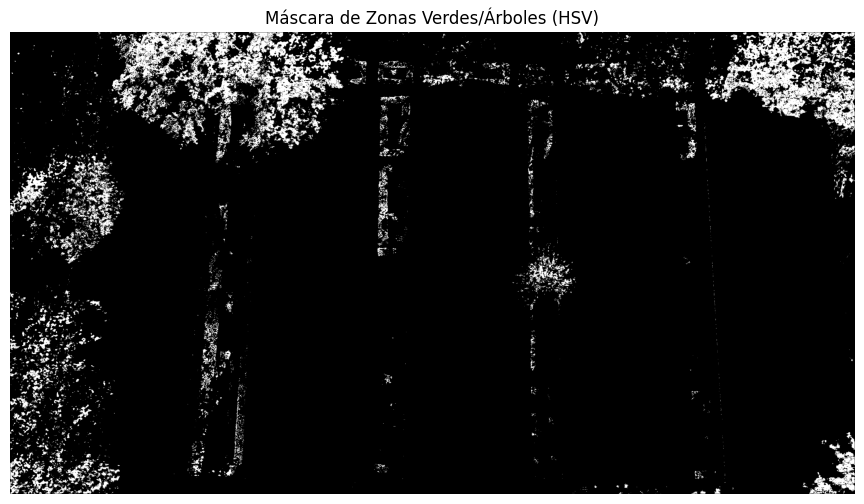

In [ ]:
# Convertir ROI a HSV
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_RGB2HSV)

# Nuevos rangos HSV para detectar zonas verdes (ajusta si es necesario)
# Estos son rangos generales para el verde, es posible que necesites afinar H (tono)
# Lower/Upper Green: [Hue_min, Saturation_min, Value_min] a [Hue_max, Saturation_max, Value_max]
# H: Tono (0-179), S: Saturación (0-255), V: Brillo (0-255)
lower_green = np.array([35, 40, 40])  # Un verde más claro/menos saturado
upper_green = np.array([85, 255, 255]) # Un verde más oscuro/saturado

# Crear máscara para el verde
mask_roi = cv2.inRange(roi_hsv, lower_green, upper_green)

# Mostrar máscara de zonas verdes
plt.figure(figsize=(12,6))
plt.imshow(mask_roi, cmap='gray')
plt.title("Máscara de Zonas Verdes/Árboles (HSV)")
plt.axis("off")
plt.show()

**Segmentación inicial mediante umbrales HSV**

Se aplicó una umbralización en el espacio HSV para separar las regiones asociadas a las zonas verdes de color claro. La máscara binaria representa en color blanco las regiones detectadas dentro del rango espectral seleccionado.

# **Separación de regiones zonas verdes**

Debido a que algunas piscinas aparecían unidas dentro de la máscara binaria, se utilizó el algoritmo HVS para separar regiones conectadas en este caso arboles o zonas verdes CLARAS y asi poder mejorar el conteo automático.

# Analisis de sensibilidad

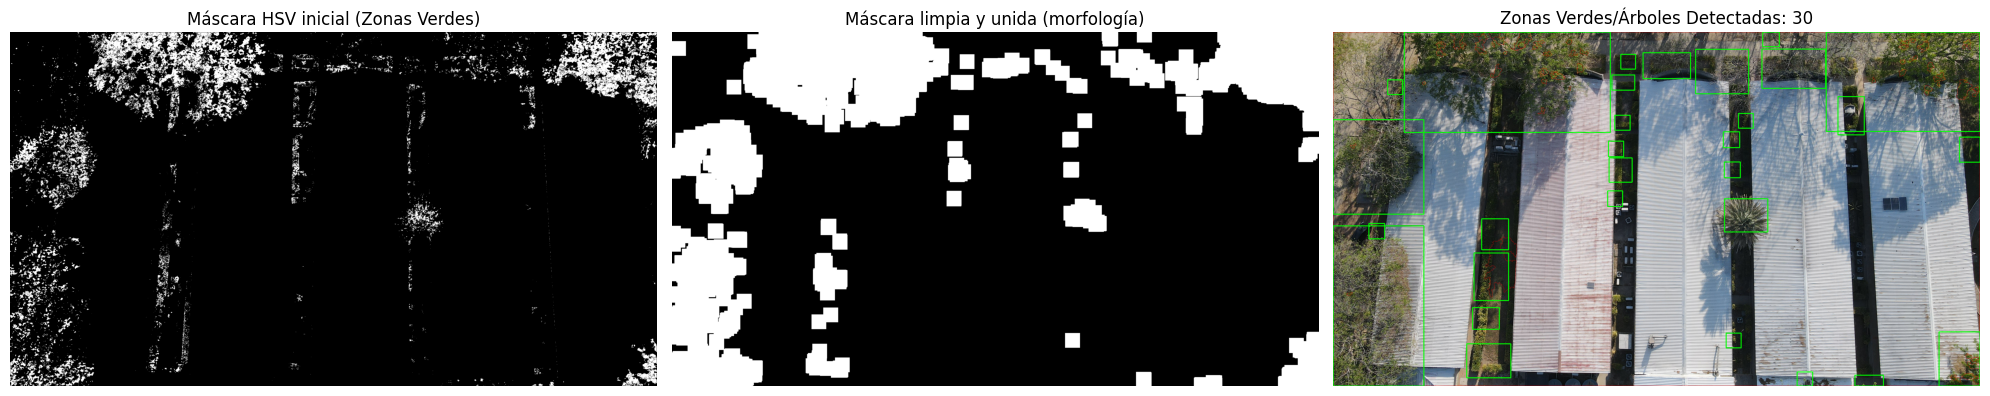

Número de Zonas Verdes/Árboles detectadas: 30
Parámetros usados: H_min=35, S_min=40, V_min=40, H_max=85, S_max=255, V_max=255, Clean_Kernel=5, Clean_Iterations=1, Merge_Kernel=35, Merge_Iterations=2, Min_Area=5000


In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import cv2
import numpy as np

def analyze_sensitivity(
    h_min, s_min, v_min, h_max, s_max, v_max,
    clean_kernel_size, clean_iterations,
    merge_kernel_size, merge_iterations,
    min_area_val
):
    # Reconstruct HSV bounds
    lower_bound = np.array([h_min, s_min, v_min])
    upper_bound = np.array([h_max, s_max, v_max])

    # 1. Initial segmentation using HSV thresholds
    mask_hsv_current = cv2.inRange(roi_hsv, lower_bound, upper_bound)

    # 2. Mask cleaning (Morphological OPEN)
    # Ensure kernel_size_val is odd
    clean_kernel_size = clean_kernel_size if clean_kernel_size % 2 != 0 else clean_kernel_size + 1
    clean_kernel = np.ones((clean_kernel_size, clean_kernel_size), np.uint8)
    mask_cleaned = cv2.morphologyEx(mask_hsv_current, cv2.MORPH_OPEN, clean_kernel, iterations=clean_iterations)

    # 3. Merge (Morphological DILATE to connect nearby regions)
    merge_kernel_size = merge_kernel_size if merge_kernel_size % 2 != 0 else merge_kernel_size + 1
    merge_kernel = np.ones((merge_kernel_size, merge_kernel_size), np.uint8)
    mask_merged = cv2.dilate(mask_cleaned, merge_kernel, iterations=merge_iterations)

    # 4. Find Contours
    contours, _ = cv2.findContours(mask_merged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    num_green_zones = 0
    resultado_current = roi.copy() # Draw on a copy of the ROI

    # 5. Filter by Area and Draw Bounding Boxes
    for c in contours:
        area = cv2.contourArea(c)

        if area > min_area_val:
            x, y, w, h = cv2.boundingRect(c)
            cv2.rectangle(resultado_current, (x, y), (x + w, y + h), (0, 255, 0), 3) # Green bounding box
            num_green_zones += 1

    # Display results
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(mask_hsv_current, cmap='gray')
    axes[0].set_title("Máscara HSV inicial (Zonas Verdes)")
    axes[0].axis("off")

    axes[1].imshow(mask_merged, cmap='gray')
    axes[1].set_title("Máscara limpia y unida (morfología)")
    axes[1].axis("off")

    axes[2].imshow(resultado_current)
    axes[2].set_title(f"Zonas Verdes/Árboles Detectadas: {num_green_zones}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Número de Zonas Verdes/Árboles detectadas: {num_green_zones}")
    print(f"Parámetros usados: H_min={h_min}, S_min={s_min}, V_min={v_min}, H_max={h_max}, S_max={s_max}, V_max={v_max}, Clean_Kernel={clean_kernel_size}, Clean_Iterations={clean_iterations}, Merge_Kernel={merge_kernel_size}, Merge_Iterations={merge_iterations}, Min_Area={min_area_val}")


# Create widgets for parameters with initial values based on green zone detection
h_min_slider = widgets.IntSlider(min=0, max=179, step=1, value=35, description='H Min')
s_min_slider = widgets.IntSlider(min=0, max=255, step=1, value=40, description='S Min')
v_min_slider = widgets.IntSlider(min=0, max=255, step=1, value=40, description='V Min')

h_max_slider = widgets.IntSlider(min=0, max=179, step=1, value=85, description='H Max')
s_max_slider = widgets.IntSlider(min=0, max=255, step=1, value=255, description='S Max')
v_max_slider = widgets.IntSlider(min=0, max=255, step=1, value=255, description='V Max')

clean_kernel_size_slider = widgets.IntSlider(min=1, max=21, step=2, value=5, description='Clean Kernel Size') # For MORPH_OPEN
clean_iterations_slider = widgets.IntSlider(min=1, max=5, step=1, value=1, description='Clean Iterations')

merge_kernel_size_slider = widgets.IntSlider(min=1, max=51, step=2, value=35, description='Merge Kernel Size') # For DILATE
merge_iterations_slider = widgets.IntSlider(min=1, max=5, step=1, value=2, description='Merge Iterations')

min_area_slider = widgets.IntSlider(min=100, max=10000, step=100, value=5000, description='Min Area') # Adjusted for green zones

# Link widgets to the function
sensitivity_widget = widgets.interactive(
    analyze_sensitivity,
    h_min=h_min_slider, s_min=s_min_slider, v_min=v_min_slider,
    h_max=h_max_slider, s_max=s_max_slider, v_max=v_max_slider,
    clean_kernel_size=clean_kernel_size_slider,
    clean_iterations=clean_iterations_slider,
    merge_kernel_size=merge_kernel_size_slider,
    merge_iterations=merge_iterations_slider,
    min_area_val=min_area_slider
)

display(sensitivity_widget)

#**Análisis del resultado**

El algoritmo detectó automáticamente 31 árboles y zonas verdes mediante segmentación en el espacio de color HSV, aplicando operaciones morfológicas para la reducción de ruido y la posterior separación de regiones mediante el algoritmo de Watershed. El proceso de segmentación se enfocó en la identificación de regiones con características espectrales asociadas a la vegetación, principalmente en el rango correspondiente a tonos verdes dentro del espectro HSV.

Algunas copas de árboles con sombras intensas o con baja diferenciación espectral respecto al entorno no pudieron ser segmentadas completamente, lo que pudo influir en la precisión del contaje final. Sin embargo, el método permitió delimitar de manera general las principales áreas de vegetación presentes en la imagen.

Por esta razón, la detección se centró exclusivamente en zonas con respuesta espectral característica de vegetación, excluyendo regiones sin firma cromática verde suficientemente definida.

# **Validación cuantitativa**

Se comparó el conteo automático obtenido por el algoritmo con el conteo manual realizado sobre la imagen original.

In [ ]:
conteo_real = 34  # conteo manual de referencia
conteo_automatico = 31  # resultado del algoritmo HSV + contornos

error_absoluto = abs(conteo_real - conteo_automatico)
error_porcentual = (error_absoluto / conteo_real) * 100

print("Conteo manual de referencia:", conteo_real)
print("Conteo automático:", conteo_automatico)
print("Error absoluto:", error_absoluto)
print("Error porcentual:", error_porcentual, "%")

Conteo manual de referencia: 34
Conteo automático: 31
Error absoluto: 3
Error porcentual: 8.823529411764707 %
